# **Multiclass Classification**

## **Summary**:

We'll work with the full wildlife dataset, which has eight classes. Here we'll build and train a more complicated neural network, called a **Convolutional Neural Network**, that is meant for working with images.

In [1]:
# pip install torchinfo

In [2]:
# Import packages
import os
import sys
from collections import Counter

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import PIL
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from torch.utils.data import DataLoader, random_split
from torchinfo import summary
from torchvision import datasets, transforms
from tqdm.notebook import tqdm

torch.backends.cudnn.deterministic = True

In [3]:
print("Platform:", sys.platform)
print("Python version:", sys.version)
print("---")
print("matplotlib version:", matplotlib.__version__)
print("pandas version:", pd.__version__)
print("PIL version:", PIL.__version__)
print("torch version:", torch.__version__)
print("torchvision version:", torchvision.__version__)

Platform: linux
Python version: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
---
matplotlib version: 3.10.0
pandas version: 2.2.2
PIL version: 11.3.0
torch version: 2.10.0+cu128
torchvision version: 0.25.0+cu128


**Objectives**:

- Read in data with multiple classes
- Normalize our data to improve performance
- Create a Convolutional Neural Network that works well with images
- Train that network to do multiclass classification
- Deploy our model

**New Terms**:

- Multiclass-
- Normalize
- Convolution
- Max pooling

In [4]:
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

print(f"Using {device} device.")

Using cuda device.


## Loading files

We'll need to read in our data. Since we'll be using images once again, we'll need to convert them to something our network can understand.

In [7]:
import os

# --- Mount Drive ---
from google.colab import drive
drive.mount('/content/drive')

train_dir = "/content/drive/MyDrive/multiclass_dataset/train"

#View the distribution for all classes
# for cls in os.listdir(train_dir):
#     cls_path = os.path.join(train_dir, cls)

#     if os.path.isdir(cls_path):
#         num_images = len(os.listdir(cls_path))
#         print(f"{cls}: {num_images}")

Mounted at /content/drive
bird: 1641
monkey_prosimian: 2492
leopard: 2254
hog: 978
civet_genet: 2423
antelope_duiker: 2474
blank: 2213
rodent: 2013


**Let's remove corrupted images if any**

In [11]:
# from PIL import Image
# import os

# bad_files = []

# for root, _, files in os.walk(train_dir):
#     for file in files:
#         path = os.path.join(root, file)

#         try:
#             with Image.open(path) as img:
#                 img.verify()  # verifies file integrity
#         except:
#             bad_files.append(path)

# print("Number of corrupted images:", len(bad_files))

# # Delete them
# for path in bad_files:
#     os.remove(path)

# print("Corrupted images removed.")

Number of corrupted images: 2
Corrupted images removed.


 ## **Transformation `function`**

 To start with, we'll use the same set of transformations we used in the previous notebook.

These transformations are
- Convert any grayscale images to RGB format with a custom class
- Resize the image, so that they're all the same size (we chose 224 x 224, but other sizes would work as well)
- Convert the image to a Tensor of pixel values

This should result in each image becoming a Tensor of size 3 x 224 x 224. We'll check this once we read in the data.

In [5]:
class ConvertToRGB:
    def __call__(self, img):
        if img.mode != "RGB":
            img = img.convert("RGB")
        return img

In [6]:
transform = transforms.Compose(
    [
        ConvertToRGB(),
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
    ]
)

Now that we have our data, let's verify that we got what we wanted. We should have classes for each of the seven animals, and one `'blank'` for when there wasn't an animal in the image. Additionally, the tensors we get should be of size $3$ x $224$ x $224$.

**In principle**, we could work with the data like this. But PyTorch is expecting the data to be broken into batches with a `DataLoader`. This prevents PyTorch from trying to load all of the files into memory at once, which would cause our notebook to crash. Instead, it loads just a few (the `batch_size`), works with them, then discards them. Since all the tools are expecting it, we should convert ours. The batch size to work with will depend on our system, but something in the $20$ to $100$ range is usually fine. We'll pick $32$.

In [12]:
dataset =  datasets.ImageFolder(train_dir, transform=transform)

batch_size = 32
dataset_loader = DataLoader(dataset, batch_size=batch_size)

# Get one batch
first_batch = next(iter(dataset_loader))

print(f"Shape of one batch: {first_batch[0].shape}")
print(f"Shape of labels: {first_batch[1].shape}")

Shape of one batch: torch.Size([32, 3, 224, 224])
Shape of labels: torch.Size([32])


Technically, we should divide our data into a training set and validation set right now. Then we should do all of our work on just the training set. This prevents information from the validation set leaking into the training set. But the way that PyTorch organizes its data loading makes that much more difficult than what we're going to do. We're going to do one simple transformation to our data, then do the test-validation split. If we were doing anything more complicated, we'd have to be more careful.

## **Preparing Our Data**

As we were reading in the data, we already did some preparation. Our images are all the same shape, and have been converted to tensors. But neural networks tend to perform best with data that has a **mean of $0$ and a standard deviation of $1$**. Data that has that property is called **_normalized_**. In our case, that would be the mean and standard deviation of all of the pixels in all of the images.

Let's see what they are for our data. Here's a **function** that computes the mean and standard deviation for each color channel (red, green, and blue) separately. It takes in a `DataLoader` and returns the mean and standard deviation of each channel.

In [13]:
def get_mean_std(loader):
    """Computes the mean and standard deviation of image data.

    Input: a `DataLoader` producing tensors of shape [batch_size, channels, pixels_x, pixels_y]
    Output: the mean of each channel as a tensor, the standard deviation of each channel as a tensor
            formatted as a tuple (means[channels], std[channels])"""

    channels_sum, channels_squared_sum, num_batches = 0, 0, 0
    for data, _ in tqdm(loader, desc="Computing mean and std", leave=False):
        channels_sum += torch.mean(data, dim=[0, 2, 3])
        channels_squared_sum += torch.mean(data**2, dim=[0, 2, 3])
        num_batches += 1
    mean = channels_sum / num_batches
    std = (channels_squared_sum / num_batches - mean**2) ** 0.5

    return mean, std

Let's run the `get_mean_std` function. on the `training data`, and save the means and standard deviations to variables `mean` and `std`. There should be a value for each color channel, giving us vectors of length $3$.

In [14]:
mean, std = get_mean_std(dataset_loader)

print(f"Mean: {mean}")
print(f"Standard deviation: {std}")

Computing mean and std:   0%|          | 0/516 [00:00<?, ?it/s]

Mean: tensor([0.4788, 0.4926, 0.4834])
Standard deviation: tensor([0.2541, 0.2470, 0.2501])


Now that we have these values, we can adjust our pixels. To get mean $0$, we need to subtract our measured `mean` from every pixel. To get standard deviation $1$, we divide every pixel by the `std`.

We can perform these calculations using the `Normalize` transformation that `torchvision` gives us. We'll add it as an extra step to the transform we created earlier. Since we're doing the three color channels separately, we'll nave to give `Normalize` a vector with three means (and the same for standard deviation). Conveniently, that's what we have.

In [15]:
# Normalizing transformation again
transform_norm = transforms.Compose(
    [
        ConvertToRGB(),
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=mean, std=std), #Normalize
    ]
)

## Normalized dataset using ImageFolder and a new DataLoader.

In [16]:
batch_size= 32
norm_dataset = datasets.ImageFolder(root=train_dir, transform=transform_norm)

norm_loader = DataLoader(norm_dataset, batch_size=batch_size)

If this did what we wanted, the normalized data should have mean
 and standard deviation
 in each color channel.

In [17]:
norm_mean, norm_std = get_mean_std(norm_loader)

print(f"Mean: {norm_mean}")
print(f"Standard deviation: {norm_std}")

Computing mean and std:   0%|          | 0/516 [00:00<?, ?it/s]

Mean: tensor([ 5.1389e-08, -4.5497e-07,  1.6547e-08])
Standard deviation: tensor([1.0000, 1.0000, 1.0000])


### Train and validation splitting

As always, we'll need to divide our data into two parts. We'll train our data on some of our images, and reserve some of them for validation. This will let us see how our model does on images it hasn't seen before. If it makes good predictions on the training data but not on the validation data, we'll know it has overfit.

In [18]:
# Important, don't change this!
g = torch.Generator()
g.manual_seed(42)

train_dataset, val_dataset = random_split(norm_dataset, [0.8, 0.2])

length_train = len(train_dataset)
length_val = len(val_dataset)
length_dataset = len(norm_dataset)
percent_train = np.round(100 * length_train / length_dataset, 2)
percent_val = np.round(100 * length_val / length_dataset, 2)

print(f"Train data is {percent_train}% of full data")
print(f"Validation data is {percent_val}% of full data")

Train data is 80.0% of full data
Validation data is 20.0% of full data


We want the training data and validation data to be similar. Ideally, the random split should do that for us. But with multiple categories, it's possible we have too much of one category ending up in training or validation.  For example, we could have gotten really unlucky and wound up with all of our leopards in the validation set.

We should check how many of each category we have in each of our data sets. We aren't expecting the same _number_ of each. The different categories started with different amounts, and the training set is $4$ times as big. But we should expect the training and validation sets to have the same _proportion_ of each category.

As we did in the last notebook, we can visualize this with a bar chart. We'll use the same function as last time.

In [19]:
def class_counts(dataset):
    c = Counter(x[1] for x in tqdm(dataset))
    class_to_index = dataset.dataset.class_to_idx
    return pd.Series({cat: c[idx] for cat, idx in class_to_index.items()})

In [20]:
train_class_distributions = class_counts(train_dataset)

train_class_distributions

  0%|          | 0/13189 [00:00<?, ?it/s]

,0
antelope_duiker,1997
bird,1303
blank,1751
civet_genet,1952
hog,750
leopard,1810
monkey_prosimian,2002
rodent,1624


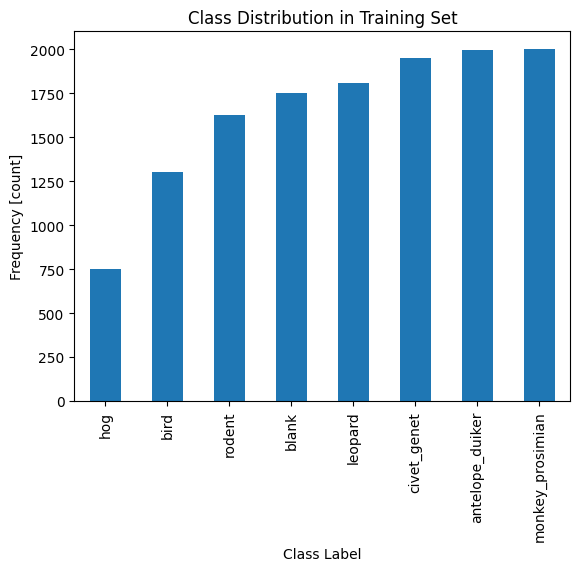

In [21]:
# Create a bar plot from train_class_distribution
train_class_distributions.sort_values().plot(kind="bar")

# Add axis labels and title
plt.xlabel("Class Label")
plt.ylabel("Frequency [count]")
plt.title("Class Distribution in Training Set");

  0%|          | 0/3297 [00:00<?, ?it/s]

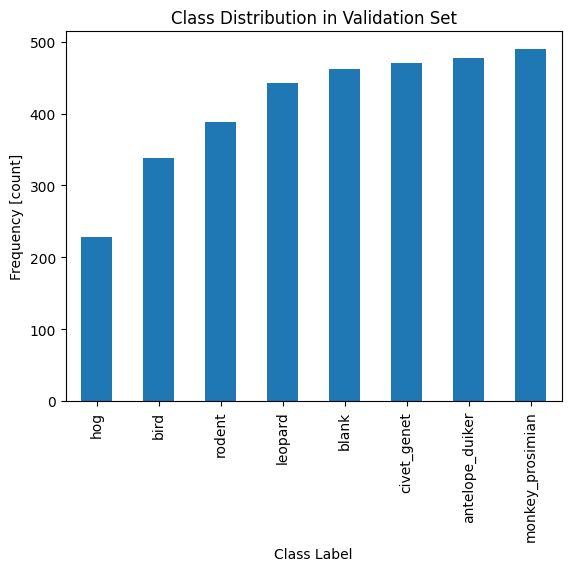

In [22]:
# Get the class distribution
validation_class_distributions = class_counts(val_dataset)

# Create a bar plot from train_class_distribution
validation_class_distributions.sort_values().plot(kind="bar")

# Add axis labels and title
plt.xlabel("Class Label")
plt.ylabel("Frequency [count]")
plt.title("Class Distribution in Validation Set");

Create data loaders for the train and validation sets. Use a batch size of
. Be sure to turn on shuffling for the training set.

In [23]:
# Important, don't change this!
g = torch.Generator()
g.manual_seed(42)


batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

val_loader = DataLoader(val_dataset, batch_size=batch_size)

single_batch = next(iter(train_loader))[0]
print(f"Shape of one batch: {single_batch.shape}")

Shape of one batch: torch.Size([32, 3, 224, 224])


# **Multiclass Predictions**

We want a model that will take a picture, and tell us what's in it. But this time, instead of just "hog" or "blank", we want it to tell us which animal is in the image. This makes it a **_multiclass_** classification problem.

Now we're going to have our model give a confidence for _each_ class. This will give us $8$ values. As before, higher numbers mean that the model is more confident that class is the right answer. A possible output for a single image would be the following.


### **Network Architecture**

Now we need a model. We'll build another neural network. The one we built last time was a shallow neural network. This is a network made of a sequence of "dense" or "fully connected" layers. But that's not the only option! You can connect the neurons in different ways, to get different _architectures_.

The shallow neural network is the "standard", most common one. We could use it for our problem, but to get good accuracy we'd need to add more layers. That network would take a long time to train. We'll be better served by using an architecture meant for images.

A good option, and the one we'll use, is the **convolutional neural network** (CNN). It consists of a sequence of convolutional and max pooling layers. These are usually followed by some fully connected layers and an output layer.

### Convolution and Max Pooling Layers

The CNN gets its name from the convolutional layers. These layers take in an image, maintaining the 2D structure, and convolve it with a number of kernels. Each kernel will produce a new image. Thankfully, PyTorch will do all the math and tracking for us. Just like we had `Linear` layers before, we can get a convolutional layer by adding a `Conv2D` to our model.

As before, we'll use a `Sequential` model to keep track of how to build things.

In [24]:
# model_seq = torch.nn.Sequential()

### **Convolution layer**

To create a convolution layer, we need to provide it with three arguments: the number of channels it expects as input, the number of kernels to create, and the size of those kernels. We don't have to specify the size of the images, it'll figure that out.

This first layer will be looking at our input images. They have three color channels, so we set `in_channels=3`. For our kernels, let's start with $16$ kernels of size $3$ x $3$. We specify the kernel size with `kernel_size=(3,3)`, and the number of kernels with `out_channels=16`. We'll also need padding to keep our image size. With a $3$ x $3$ kernel, we'll set padding to $1$.


### Note: I have provided the complete convolution layer below

# Training the Model

Before we start training, let's put all the model code in one place. This is how you'd do it in practice, to prevent errors.

We have also added `Dropout` layers after the flattened and linear layers. This helps to prevent overfitting.

In [25]:
# Important! Don't change this
torch.manual_seed(42)
torch.cuda.manual_seed(42)

model = torch.nn.Sequential()

conv1 = torch.nn.Conv2d(in_channels=3, out_channels=16, kernel_size=(3, 3), padding=1)
max_pool1 = torch.nn.MaxPool2d(kernel_size=(2, 2), stride=2)
model.append(conv1)
model.append(torch.nn.ReLU())
model.append(max_pool1)

conv2 = torch.nn.Conv2d(in_channels=16, out_channels=32, kernel_size=(3, 3), padding=1)
max_pool2 = torch.nn.MaxPool2d(kernel_size=(2, 2), stride=2)
model.append(conv2)
model.append(torch.nn.ReLU())
model.append(max_pool2)

conv3 = torch.nn.Conv2d(32, 64, 3, padding=1)
max_pool3 = torch.nn.MaxPool2d(2)
model.append(conv3)
model.append(torch.nn.ReLU())
model.append(max_pool3)

model.append(torch.nn.Flatten())
model.append(torch.nn.Dropout())

linear1 = torch.nn.Linear(in_features=50176, out_features=500)
model.append(linear1)
model.append(torch.nn.ReLU())
model.append(torch.nn.Dropout())

output_layer = torch.nn.Linear(500, 8)
model.append(output_layer)

Sequential(
  (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU()
  (2): MaxPool2d(kernel_size=(2, 2), stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (4): ReLU()
  (5): MaxPool2d(kernel_size=(2, 2), stride=2, padding=0, dilation=1, ceil_mode=False)
  (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (7): ReLU()
  (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (9): Flatten(start_dim=1, end_dim=-1)
  (10): Dropout(p=0.5, inplace=False)
  (11): Linear(in_features=50176, out_features=500, bias=True)
  (12): ReLU()
  (13): Dropout(p=0.5, inplace=False)
  (14): Linear(in_features=500, out_features=8, bias=True)
)

In [26]:
height, width = 224, 224
summary(model, input_size=(batch_size, 3, height, width))

Layer (type:depth-idx)                   Output Shape              Param #
Sequential                               [32, 8]                   --
├─Conv2d: 1-1                            [32, 16, 224, 224]        448
├─ReLU: 1-2                              [32, 16, 224, 224]        --
├─MaxPool2d: 1-3                         [32, 16, 112, 112]        --
├─Conv2d: 1-4                            [32, 32, 112, 112]        4,640
├─ReLU: 1-5                              [32, 32, 112, 112]        --
├─MaxPool2d: 1-6                         [32, 32, 56, 56]          --
├─Conv2d: 1-7                            [32, 64, 56, 56]          18,496
├─ReLU: 1-8                              [32, 64, 56, 56]          --
├─MaxPool2d: 1-9                         [32, 64, 28, 28]          --
├─Flatten: 1-10                          [32, 50176]               --
├─Dropout: 1-11                          [32, 50176]               --
├─Linear: 1-12                           [32, 500]                 25,088,500

This model has over 25 million parameters. That's fewer than our previous model, but because of the more complicated architecture it'll take more time and resources to train.

We can use the same training code we used last time. It can handle binary or multiclass classification.

In [28]:
#Define the loss_fn and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
model.to(device)

Sequential(
  (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU()
  (2): MaxPool2d(kernel_size=(2, 2), stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (4): ReLU()
  (5): MaxPool2d(kernel_size=(2, 2), stride=2, padding=0, dilation=1, ceil_mode=False)
  (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (7): ReLU()
  (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (9): Flatten(start_dim=1, end_dim=-1)
  (10): Dropout(p=0.5, inplace=False)
  (11): Linear(in_features=50176, out_features=500, bias=True)
  (12): ReLU()
  (13): Dropout(p=0.5, inplace=False)
  (14): Linear(in_features=500, out_features=8, bias=True)
)

## Regarding Model Training Times

This task involves training a neural network for 10-15 epochs. The training process is computationally intensive and can be very time-consuming. On most systems, each epoch may take between 10 and 15 minutes, meaning the entire training process could last well over one hour.

### **Training `epoch` function**

In [43]:
def train_epoch(model, optimizer, loss_fn, data_loader, device="cpu"):
    # We'll report the loss function's average value at the end of the epoch.
    training_loss = 0.0

    # The train method simply sets the model in training mode. No training
    # has happened.
    model.train()

    # We iterate over all batches in the training set to complete one epoch
    for inputs, targets in tqdm(data_loader, desc="Training", leave=False):
        # Sets the gradients to zero. We need to do this every time.
        optimizer.zero_grad()

        # Unpack images (X) and labels (y) from the batch and add those
        # tensors to the specified device.
        inputs = inputs.to(device)
        targets = targets.to(device)

        # We make a forward pass through the network and obtain the logits.
        # With the logits, we can calculate our loss.
        output = model(inputs)
        loss = loss_fn(output, targets)

        # After calculating our loss, we calculate the numerical value of
        # the derivative of our loss function with respect to all the
        # trainable model weights. Once we have the gradients calculated,
        # we let the optimizer take a "step", in other words, update or
        # adjust the model weights.
        loss.backward()
        optimizer.step()

        # We increment the training loss for the current batch
        training_loss += loss.data.item() * inputs.size(0)

    # We calculate the training loss over the completed epoch
    return training_loss / len(data_loader.dataset)

### **Let's create the `score` function**

The score function is very similar to the prediction function, but instead of gathering all the predictions, it just calculates the number of correct predictions in each batch. It also calculates the loss function over the whole batch. We'll use this to compare the loss function value on the training set and the validation set, to understand if there's any **overfitting**.

In [37]:
def score(model, data_loader, loss_fn, device="cpu"):
    # Initialize the total loss (cross entropy) and the number of correct
    # predictions. We'll increment these values as we loop through the
    # data.
    total_loss = 0
    total_correct = 0

    # We set the model to evaluation mode. This mode is the opposite of
    # train mode we set in the train_epoch function.
    model.eval()

    # Since we're not training, we don't need any gradient calculations.
    # This tells PyTorch not to calculate any gradients, which speeds up
    # some calculations.
    with torch.no_grad():
        # We iterate over the batches in the data loader and feed
        # them into the model for the forward pass.
        for inputs, targets in tqdm(data_loader, desc="Scoring", leave=False):
            inputs = inputs.to(device)
            output = model(inputs)

            # Calculating the loss function for this batch
            targets = targets.to(device)
            loss = loss_fn(output, targets)
            total_loss += loss.data.item() * inputs.size(0)

            # Calculating the correct predictions for this batch
            correct = torch.eq(torch.argmax(output, dim=1), targets)
            total_correct += torch.sum(correct).item()

    return total_loss / len(data_loader.dataset), total_correct / len(
        data_loader.dataset
    )

### **Let's create the `train` function**

In [36]:
def train(model, optimizer, loss_fn, train_loader, val_loader, epochs=20, device="cpu"):

    for epoch in range(1, epochs + 1):
        # Run train_epoch once, and capture the training loss.
        training_loss = train_epoch(model, optimizer, loss_fn, train_loader, device)

        # Score the model on the validation data.
        validation_loss, validation_accuracy = score(model, val_loader, loss_fn, device)

        print(
            f"Epoch: {epoch}, Training Loss: {training_loss:.2f}, "
            f"Validation Loss: {validation_loss:.2f}, Validation Accuracy: {validation_accuracy:.2f}"
        )

### Let's train our model for few `epochs`

In [39]:
train(model, optimizer, loss_fn, train_loader, val_loader, epochs=1, device=device)

Epoch: 1, Training Loss: 0.17, Validation Loss: 0.60, Validation Accuracy: 0.86


**Let's create a `Prediction function`**

In [46]:
import torch.nn.functional as F

def predict(model, data_loader, device="cpu"):
    # This tensor will store all of the predictions.
    all_probs = torch.tensor([]).to(device)

    # We set the model to evaluation mode. This mode is the opposite of
    # train mode we set in the train_epoch function.
    model.eval()

    # Since we're not training, we don't need any gradient calculations.
    # This tells PyTorch not to calculate any gradients, which speeds up
    # some calculations.
    with torch.no_grad():

        # Again, we iterate over the batches in the data loader and feed
        # them into the model for the forward pass.
        for inputs, targets in tqdm(data_loader, desc="Predicting", leave=False):
            inputs = inputs.to(device)
            output = model(inputs)

            # The model produces the logits.  This softmax function turns the
            # logits into probabilities.  These probabilities are concatenated
            # into the `all_probs` tensor.
            probs = F.softmax(output, dim=1)
            all_probs = torch.cat((all_probs, probs), dim=0)

    return all_probs

In [48]:
# Calculating the predictions using the `val_loader`.
probabilities = predict(model, val_loader, device)
predictions = torch.argmax(probabilities, dim=1)

tensor(6, device='cuda:0')

In [50]:
# With the correct answers, we can generate the confusion matrix. Let's pull the targets into a list.
targets = []

for _, labels in tqdm(val_loader):
    targets.extend(labels.tolist())

100%|██████████| 104/104 [00:26<00:00,  3.93it/s]


In [51]:
#View 10 targets
targets[:10]

[6, 0, 2, 2, 2, 1, 6, 5, 1, 6]

**Create a confusion matrix**

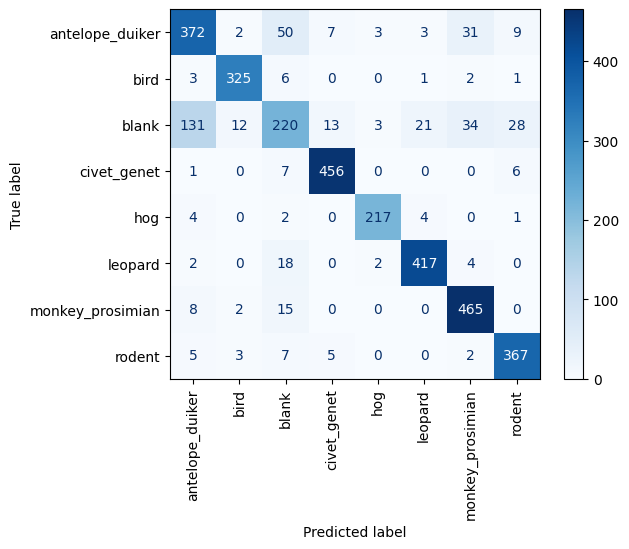

In [55]:
# get class names
classes = val_loader.dataset.dataset.classes

# confusion matrix
cm = confusion_matrix(targets, predictions.cpu())

# display
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)

disp.plot(cmap=plt.cm.Blues, xticks_rotation="vertical")
plt.show()

We're doing at least as well as our binary classification, but this time with many more animal choices. It seems some animals are a bit more difficult to distinguish from the 'blank' images.

### **Saving the Model**

The training has determined what the best parameters (also called weights) for our network. The only information we need to reproduce it's the network architecture, and the values of those parameters. PyTorch lets us save all of this. Then we can just load the model in the future instead of having to **retrain** it.

In [ ]:
# Save it Permanently to your `Google Drive`
folder_path = "/content/drive/MyDrive/hog_blank_datasets/model"

# Define a FILENAME (e.g., myModel.pth) inside that folder
file_path = os.path.join(folder_path, "neuralnet.pth")

# Save the weights
torch.save(model.state_dict(), file_path)
print(f"Success! Model saved to: {file_path}")

# **Conclusion**

Good work! This was a long one, but we covered a lot of important ideas. We're now able to use PyTorch to classify any number of images, with any number of classes! Here are the key takeaways:

- Some preprocessing of our images, or data in general, can help our models.
- In multiclass classification, we get a confidence for each of our classes.
- Neural networks can have different ways of connecting their neurons, called architectures
- The Convolutional Neural Network architecture does well on images
- In PyTorch, we can build one by choosing different layers
- With a trained model, we can predict the class of an unlabeled image

All together, this let us complete what we have been working on. We now have a model that gives us confidences (and thus predictions) on what animals appear in a camera trap image.